## Intrinsic Value Analysis Model Training

Intrinsic value is an estimation of a stock’s “real” price based on fundamental metrics. Having this principle in mind, a system can be created which looks at common trends within market sectors on what constitutes as a cheap stock vs an expensive stock. The metrics being used in this case are; the P/E ratio and Intrinsic value defined by Benjamin Graham’s formula and the predictions of a GMM on sector specific possibilities of a stock being cheap or expensive based on the other two metrics.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
from sqlalchemy import exc, create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.mixture import GaussianMixture
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

#### Loading data and Pre-processing

At this stage the data is loaded from the local MS express server into a Pandas dataframe. Then one-hot encoding is performed on valuation labels like "undervalued" and "overvalued" which are converted to to 1 and 0 respectively. The sectors however are kept as strings to be used as filters within the GMM.

In [68]:
sql_server = 'SERVER=localhost\\SQLEXPRESS'
database_name = 'DATABASE=stock_metrics'
driver = 'DRIVER=ODBC Driver 17 for SQL Server'
params = f"{driver};{sql_server};{database_name};Trusted_Connection=yes;"
conn_str = f"mssql+pyodbc:///?odbc_connect={params}"


# tables from the local sql database:
# stocks (ticker, stock_name, sector, price, earnings, pe_ratio, market_cap)
# growth_rates (ticker, start_value, end_value, growth_rate, corp_bond_yield)
# historic_valuations (ticker, valuation)
def load_data():
    filterwarnings("ignore", category=exc.SAWarning)
    engine = create_engine(conn_str)
    query = """
    SELECT 
        s.ticker, s.sector, s.price, s.earnings, s.pe_ratio, 
        g.growth_rate, g.corp_bond_yield, h.valuation
    FROM dbo.stocks s
    JOIN dbo.growth_rates g ON s.ticker = g.ticker
    JOIN dbo.historic_valuations h ON s.ticker = h.ticker
    """
    df = pd.read_sql(query, engine)
    return df


stocks_dataframe = load_data()
stocks_dataframe['valuation'] = stocks_dataframe['valuation'].map({
    'undervalued': 1, 'overvalued': 0
})
display(stocks_dataframe.head(10))

,ticker,sector,price,earnings,pe_ratio,growth_rate,corp_bond_yield,valuation
0,A,Health Care,65.05,2.10,27.45,0.36,2.67,1
1,AAL,Industrials,48.60,3.91,9.92,-0.22,2.67,1
2,AAOI,Technology,149.42,-0.65,0.00,-0.22,2.67,1
3,AAON,Industrials,96.86,1.29,75.09,0.18,2.67,1
4,AAP,Consumer Discretionary,109.63,6.19,19.54,0.08,2.67,0
5,AAPL,Information Technology,155.15,9.20,16.86,0.56,2.67,1
6,AAT,Real Estate,20.64,0.92,22.43,-0.08,2.67,1
7,ABBV,Health Care,108.48,3.29,19.41,0.25,2.67,1
8,ABCB,Financial Services,83.85,6.00,13.97,-0.04,2.67,1
9,ABEO,Healthcare,5.40,1.01,5.34,-0.26,2.67,0


This next step adds a new column to the stocks dataframe which introduces the calculated IV difference. This difference can then be used by the GMM to separate various sectors of stocks into two groups, cheap and expensive. The correlation this creates is that it tells the neural net later on within which sectors what values of P/E ratios, and IV differences actually contributes to undervalued or overvalued stocks, assuming different sectors even when producing the same values of IV and P/E within individual assets would create different valuations.

In [69]:
# intrinsic value formula: IV = (Earnings * (8.5 + 2 * Growth Rate) * 4.4) / Corporate Bond Yield
# GMM is trained and produces patterns for cheap vs expensive stocks based on data from 2021
# the neural net then sees the real labeled results based on data from 2021 - 2025 thus, learns to accept or veto GMM suggestions
def calculate_iv(row):
    if row['price'] <= 0 or row['corp_bond_yield'] <= 0 or np.isnan(row['price']):
        return None
    iv = (row['earnings'] * (8.5 + 2 * row['growth_rate']) * 4.4) / row['corp_bond_yield']
    return (iv - row['price']) / row['price']

stocks_dataframe['iv_diff'] = stocks_dataframe.apply(calculate_iv, axis=1)
display(stocks_dataframe.head(10))

,ticker,sector,price,earnings,pe_ratio,growth_rate,corp_bond_yield,valuation,iv_diff
0,A,Health Care,65.05,2.10,27.45,0.36,2.67,1,-0.509494
1,AAL,Industrials,48.60,3.91,9.92,-0.22,2.67,1,0.068604
2,AAOI,Technology,149.42,-0.65,0.00,-0.22,2.67,1,-1.057780
3,AAON,Industrials,96.86,1.29,75.09,0.18,2.67,1,-0.805544
4,AAP,Consumer Discretionary,109.63,6.19,19.54,0.08,2.67,0,-0.194212
5,AAPL,Information Technology,155.15,9.20,16.86,0.56,2.67,1,-0.059947
6,AAT,Real Estate,20.64,0.92,22.43,-0.08,2.67,1,-0.387388
7,ABBV,Health Care,108.48,3.29,19.41,0.25,2.67,1,-0.550189
8,ABCB,Financial Services,83.85,6.00,13.97,-0.04,2.67,1,-0.007109
9,ABEO,Healthcare,5.40,1.01,5.34,-0.26,2.67,0,1.459642


#### Model Training

Using the GMM model to find clusters of undervalued and overvalued assets. Each asset will be scored on a percentage bases, how much of the total 100% is it likely to be undervalued and how much is it likely to be overvalued and whichever value is larger the asset reflects that valuation, is the weight of the percentage score of it being overvalued is larger then it is overvalued and vise versa.

In [70]:
stocks_dataframe['gmm_prob_undervalued'] = 0.0
stocks_dataframe['gmm_prob_overvalued']  = 0.0

for sector in stocks_dataframe['sector'].unique():
    sector_mask = stocks_dataframe['sector'] == sector
    sector_data = stocks_dataframe.loc[sector_mask, ['pe_ratio', 'iv_diff']].dropna()
    if len(sector_data) < 2:
        continue
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(sector_data)
    probability = gmm.predict_proba(sector_data) 
    undervalued_cluster_idx = np.argmax(gmm.means_[:, 1])
    overvalued_cluster_idx = 1 - undervalued_cluster_idx
    stocks_dataframe.loc[sector_data.index, 'gmm_prob_undervalued'] = np.round(probability[:, undervalued_cluster_idx], 2)
    stocks_dataframe.loc[sector_data.index, 'gmm_prob_overvalued']  = np.round(probability[:, overvalued_cluster_idx], 2)

display(stocks_dataframe.head(10))

,ticker,sector,price,earnings,pe_ratio,growth_rate,corp_bond_yield,valuation,iv_diff,gmm_prob_undervalued,gmm_prob_overvalued
0,A,Health Care,65.05,2.10,27.45,0.36,2.67,1,-0.509494,1.0,0.0
1,AAL,Industrials,48.60,3.91,9.92,-0.22,2.67,1,0.068604,1.0,0.0
2,AAOI,Technology,149.42,-0.65,0.00,-0.22,2.67,1,-1.057780,0.0,1.0
3,AAON,Industrials,96.86,1.29,75.09,0.18,2.67,1,-0.805544,1.0,0.0
4,AAP,Consumer Discretionary,109.63,6.19,19.54,0.08,2.67,0,-0.194212,0.0,1.0
5,AAPL,Information Technology,155.15,9.20,16.86,0.56,2.67,1,-0.059947,1.0,0.0
6,AAT,Real Estate,20.64,0.92,22.43,-0.08,2.67,1,-0.387388,0.0,1.0
7,ABBV,Health Care,108.48,3.29,19.41,0.25,2.67,1,-0.550189,1.0,0.0
8,ABCB,Financial Services,83.85,6.00,13.97,-0.04,2.67,1,-0.007109,1.0,0.0
9,ABEO,Healthcare,5.40,1.01,5.34,-0.26,2.67,0,1.459642,1.0,0.0


The GMM provided probabilities are passed onto the neural net, along with the P/E ratio and IV differences as the (x) features. Meanwhile, the (y) feature is the real stock movements which occurred between 2021 - 2025 as label encoded into the 'valuation' column of the dataframe.

In [71]:
features = [
    'pe_ratio', 'iv_diff', 'growth_rate',
    'earnings', 'price', 'corp_bond_yield',
    'gmm_prob_undervalued', 'gmm_prob_overvalued'
]
df_final = pd.get_dummies(stocks_dataframe, columns=['sector'])
sector_columns = [col for col in df_final.columns if col.startswith('sector_')]
X_columns = features + sector_columns
df_final = df_final.dropna(subset=X_columns + ['valuation'])
display(df_final.head(10))

,ticker,price,earnings,pe_ratio,growth_rate,corp_bond_yield,valuation,iv_diff,gmm_prob_undervalued,gmm_prob_overvalued,...,sector_Healthcare,sector_Income,sector_Industrials,sector_Information Technology,sector_Materials,sector_Mining,sector_Real Estate,sector_Technology,sector_Telecommunication Services,sector_Utilities
0,A,65.05,2.10,27.45,0.36,2.67,1,-0.509494,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,AAL,48.60,3.91,9.92,-0.22,2.67,1,0.068604,1.0,0.0,...,False,False,True,False,False,False,False,False,False,False
2,AAOI,149.42,-0.65,0.00,-0.22,2.67,1,-1.057780,0.0,1.0,...,False,False,False,False,False,False,False,True,False,False
3,AAON,96.86,1.29,75.09,0.18,2.67,1,-0.805544,1.0,0.0,...,False,False,True,False,False,False,False,False,False,False
4,AAP,109.63,6.19,19.54,0.08,2.67,0,-0.194212,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
5,AAPL,155.15,9.20,16.86,0.56,2.67,1,-0.059947,1.0,0.0,...,False,False,False,True,False,False,False,False,False,False
6,AAT,20.64,0.92,22.43,-0.08,2.67,1,-0.387388,0.0,1.0,...,False,False,False,False,False,False,True,False,False,False
7,ABBV,108.48,3.29,19.41,0.25,2.67,1,-0.550189,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
8,ABCB,83.85,6.00,13.97,-0.04,2.67,1,-0.007109,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
9,ABEO,5.40,1.01,5.34,-0.26,2.67,0,1.459642,1.0,0.0,...,True,False,False,False,False,False,False,False,False,False


In [72]:
X = df_final[X_columns]
y = df_final['valuation']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu', solver='adam',
    alpha=0.01, learning_rate_init=0.0001,
    max_iter=2000, validation_fraction=0.1, 
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)

# Threshold logic and evaluation output
y_prob = nn_model.predict_proba(X_test_scaled)[:, 1]
y_pred_custom = (y_prob >= 0.6).astype(int)
print("--- Evaluation with a Threshold ---")
print(classification_report(y_test, y_pred_custom))

--- Evaluation with a Threshold ---
              precision    recall  f1-score   support

           0       0.75      0.78      0.76        85
           1       0.77      0.74      0.76        86

    accuracy                           0.76       171
   macro avg       0.76      0.76      0.76       171
weighted avg       0.76      0.76      0.76       171



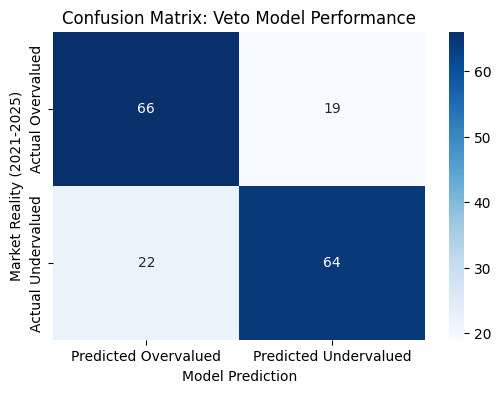

In [73]:
cm = confusion_matrix(y_test, y_pred_custom)

# Plotting
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Overvalued', 'Predicted Undervalued'],
            yticklabels=['Actual Overvalued', 'Actual Undervalued'])
plt.xlabel('Model Prediction')
plt.ylabel('Market Reality (2021-2025)')
plt.title('Confusion Matrix: Veto Model Performance')
plt.show()